# Grafiken für Methodik-Review

Erzeugt alle Abbildungen für den Foliensatz aus den Ergebnis-Dateien der drei Teilmodelle. Jede
Grafik hat ihre eigene Zelle und wird zusätzlich als PNG nach `figures/` exportiert.

**Übersicht**

| Abschnitt | Grafik | Zelle |
|---|---|---|
| Data Centers | EU-26 Gesamtnachfrage nach Szenario | `fig_dc_eu26` |
| Data Centers | Länderbeispiele 2060 (Balken) | `fig_dc_countries` |
| Data Centers | Länder gestapelt nach Szenario | `fig_dc_stacked` |
| Data Centers | Rang-Entwicklung Top-10 (Bump-Chart mit Flaggen) | `fig_dc_bump` |
| Gebäudebestand | Beobachtete vs. konstante Bauaktivität | `fig_newbuild` |
| Gebäudebestand | thermal_index Berechnung (DE 2020) | `fig_thermal_calc` |
| Gebäudebestand | Flächenentwicklung nach Klasse | `fig_stock_evolution` |
| Gebäudebestand | thermal_index nach Szenario | `fig_ti_scenarios` |
| Heat Pumps | Strombedarf je Land und Szenario | `fig_hp_grid` |
| Buildings | Strombedarf je Land und Szenario | `fig_br_grid` |
| Heat Pumps | Anteil Wärmepumpen je Land und Szenario | `fig_hp_share` |
| Gesamt | EU-26 Gesamtnachfrage gestapelt nach Sektor | `fig_total_stack_eu` |
| Gesamt | Gesamtnachfrage je Land und Szenario | `fig_total_grid` |
| Gesamt | Sektor-Mix der Gesamtnachfrage (Anteile) | `fig_total_share_eu` |

**Eingabedateien** (im selben Ordner, sonst Pfade unten anpassen)
- `floor_panel_2010_2060.csv` – Gebäudebestands-Panel
- `hp_demand_proj.csv` – Heat-Pump-Ergebnisse
- `building_demand_proj.csv` – Buildings-Ergebnisse
- `data_centers_demand.xlsx` – Data-Center-Ergebnisse (Sheet `dc_model_results`)
- `heat_pump_backtest.png` (optional) – schon vorhandenes Backtesting-Bild

Backtesting-Bild und Parameter-Tabellen kommen direkt aus den Modell-Notebooks und werden hier
nicht noch mal erzeugt.

---

## 1. Setup

Farben, Schriftgrößen, Szenario-Zuordnung – einmal festgelegt, gilt für alle Grafiken.
Orientiert sich am Design des Foliensatzes.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- file paths (adjust if your files live elsewhere) ----
PATH_FLOOR   = "Data - raw/prepared_data/floor_panel_2010_2060.csv"
PATH_HP      = "Results/hp_demand_proj.csv"
PATH_BUILD   = "Results/building_demand_proj.csv"
PATH_DC      = "Results/data_centers_demand.xlsx"
OUTDIR       = "figures"
os.makedirs(OUTDIR, exist_ok=True)

# ---- colour palette (EnBW-approximated, identical to the deck) ----
NAVY   = "#0B2B52"
BLUE   = "#1C5FA8"
ORANGE = "#EE7203"
GRAY   = "#8A8A8A"
GREEN  = "#5B8C6E"
INK    = "#222222"

# scenario -> colour and line style, used consistently everywhere
SC_COL   = {"KKO": BLUE, "KVE": GRAY, "VWE": ORANGE, "VNI": NAVY}
SC_ORDER = ["VWE", "KKO", "KVE", "VNI"]   # plotting order (front to back)

# cohort colours for the building-stock charts: old = warm/dark, new = cool, renovated = green
COH_COL = {
    "0-1945": "#7A1E12", "1946-1969": "#B5451B", "1970-1979": "#EE7203",
    "1980-1989": "#E8A24A", "1990-1999": "#7FA8C9", "2000-2010": "#3E77AC",
    "2011-2020": "#1C5FA8", "post-2020": "#0B2B52", "renovated": "#5B8C6E",
}

# heat-demand intensity per construction cohort (kWh/m2a), used for the thermal_index chart
# imported from scenario_config.py so this stays in sync with floor_area_panel.ipynb's BASE_INTENSITY
from scenario_config import BASE_INTENSITY as INTENSITY

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.edgecolor": "#CCCCCC",
    "axes.linewidth": 0.8,
    "axes.grid": True,
    "grid.color": "#E6E6E6",
    "grid.linewidth": 0.7,
    "axes.axisbelow": True,
    "figure.dpi": 110,
})

# example country used for the single-country building-stock figures
COUNTRY = "Germany"

def save(fig, name):
    """Save a figure as a high-resolution PNG into the figures/ folder."""
    path = os.path.join(OUTDIR, name + ".png")
    fig.savefig(path, dpi=170, bbox_inches="tight")
    print("saved", path)

## 2. Daten laden

Ergebnis-Dateien einlesen, kurz auf Vollständigkeit checken.

In [2]:
floor = pd.read_csv(PATH_FLOOR)
hp    = pd.read_csv(PATH_HP)
build = pd.read_csv(PATH_BUILD)

# Data Centers: wide sheet (country, scenario, 2024..2060) -> long format
dc_wide = pd.read_excel(PATH_DC, sheet_name="dc_model_results")
year_cols = [c for c in dc_wide.columns if str(c).isdigit()]
dc = dc_wide.melt(id_vars=["country", "scenario"], value_vars=year_cols,
                  var_name="year", value_name="Demand_DC_TWh")
dc["year"] = dc["year"].astype(int)

for name, df in [("floor", floor), ("hp", hp), ("build", build), ("dc", dc)]:
    print(f"{name:6s}: {df.shape[0]:5d} rows | "
          f"{df.country.nunique()} countries | "
          f"scenarios {sorted(df.scenario.unique())}")

floor :  1638 rows | 26 countries | scenarios ['HIST', 'KKO', 'KVE', 'VNI', 'VWE']
hp    :  1248 rows | 26 countries | scenarios ['KKO', 'KVE', 'VNI', 'VWE']
build :  1248 rows | 26 countries | scenarios ['KKO', 'KVE', 'VNI', 'VWE']
dc    :  3848 rows | 26 countries | scenarios ['KKO', 'KVE', 'VNI', 'VWE']


## 3. Data Centers

### 3.1 EU-26 Gesamtnachfrage nach Szenario

saved figures/fig_dc_eu26.png


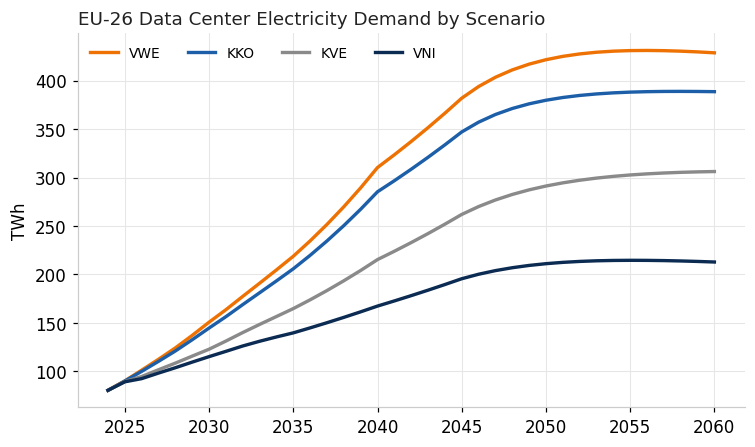

In [3]:
eu = dc.groupby(["scenario", "year"])["Demand_DC_TWh"].sum().reset_index()

fig, ax = plt.subplots(figsize=(7.0, 4.2))
for sc in SC_ORDER:
    d = eu[eu.scenario == sc].sort_values("year")
    ax.plot(d.year, d.Demand_DC_TWh, color=SC_COL[sc], lw=2.2, label=sc)
ax.set_ylabel("TWh"); ax.set_xlabel("")
ax.set_title("EU-26 Data Center Electricity Demand by Scenario", loc="left", fontsize=12, color=INK)
ax.legend(ncol=4, fontsize=9, frameon=False, loc="upper left")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
save(fig, "fig_dc_eu26")
plt.show()

### 3.2 Länderbeispiele 2060 (Balken)

Vier Länder als Beispiel, Balken gruppiert nach Szenario, für 2060.

saved figures/fig_dc_countries.png


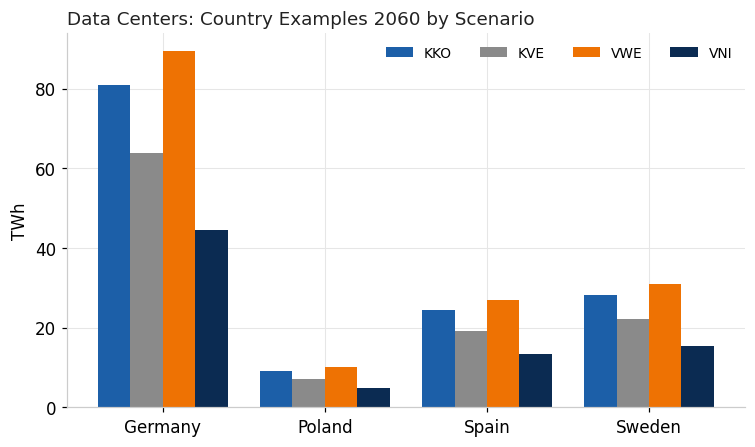

In [4]:
COUNTRIES_DC = ["Germany", "Poland", "Spain", "Sweden"]
d2060 = dc[(dc.year == 2060) & (dc.country.isin(COUNTRIES_DC))]

fig, ax = plt.subplots(figsize=(7.0, 4.2))
x = np.arange(len(COUNTRIES_DC)); wbar = 0.2
for i, sc in enumerate(["KKO", "KVE", "VWE", "VNI"]):
    vals = [d2060[(d2060.country == c) & (d2060.scenario == sc)]["Demand_DC_TWh"].values[0]
            for c in COUNTRIES_DC]
    ax.bar(x + (i - 1.5) * wbar, vals, wbar, color=SC_COL[sc], label=sc)
ax.set_xticks(x); ax.set_xticklabels(COUNTRIES_DC)
ax.set_ylabel("TWh")
ax.set_title("Data Centers: Country Examples 2060 by Scenario", loc="left", fontsize=12, color=INK)
ax.legend(ncol=4, fontsize=9, frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
save(fig, "fig_dc_countries")
plt.show()

### 3.3 Stacked Bar: Länderanteile an der EU-26-Nachfrage

Alle 26 Länder gestapelt pro Jahr, ein Szenario (Standard: KKO). Sortiert nach Nachfrage im
ersten verfügbaren Jahr, größtes Land unten im Stapel.

saved figures/fig_dc_stacked.png


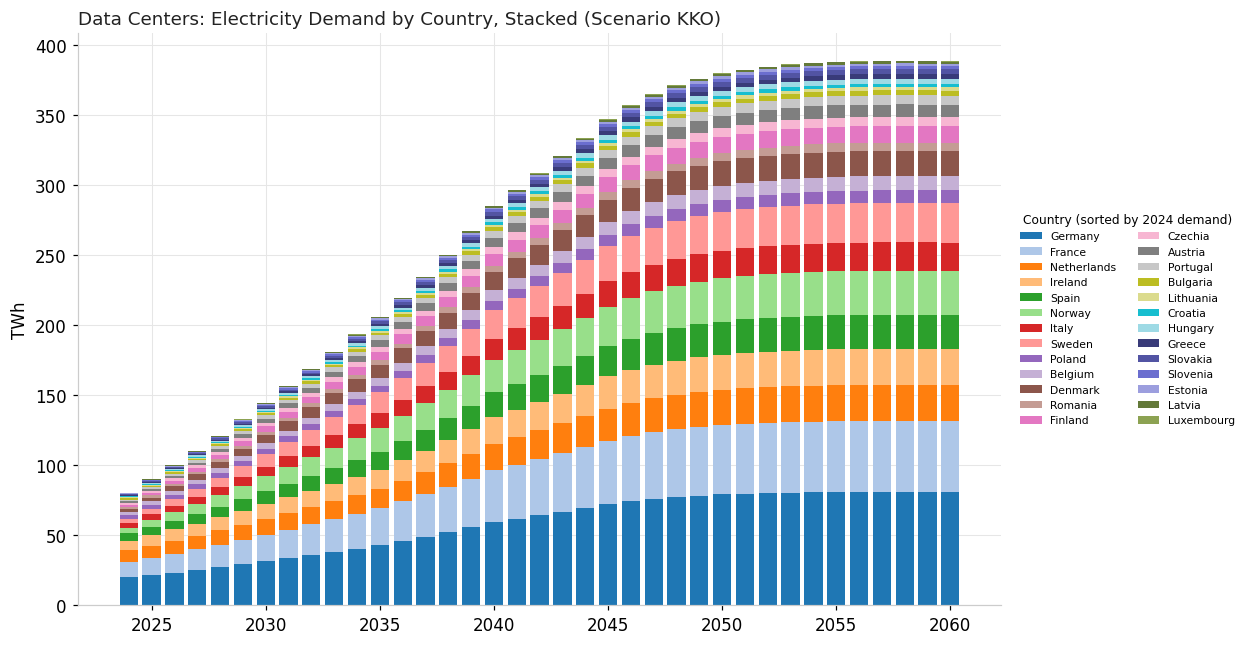

In [5]:
def dc_country_colors(scenario="KKO"):
    """Consistent colour per country, ranked by demand in the first available year.
    Reused by dc_stacked_bar and dc_bump so both figures share the same country colours."""
    d = dc[dc.scenario == scenario]
    pivot = d.pivot(index="country", columns="year", values="Demand_DC_TWh").fillna(0)
    first_year = pivot.columns.min()
    order = pivot[first_year].sort_values(ascending=False).index
    palette = plt.cm.tab20.colors + plt.cm.tab20b.colors
    return {c: palette[i] for i, c in enumerate(order)}

def dc_stacked_bar(scenario="KKO"):
    d = dc[dc.scenario == scenario]
    pivot = d.pivot(index="country", columns="year", values="Demand_DC_TWh").fillna(0)
    first_year = pivot.columns.min()
    order = pivot[first_year].sort_values(ascending=False).index
    pivot = pivot.loc[order]

    years = pivot.columns.values
    country_colors = dc_country_colors(scenario)
    colors = [country_colors[c] for c in pivot.index]

    fig, ax = plt.subplots(figsize=(11.5, 6.0))
    bottom = np.zeros(len(years))
    for color, country in zip(colors, pivot.index):
        vals = pivot.loc[country].values
        ax.bar(years, vals, bottom=bottom, color=color, width=0.8, label=country)
        bottom += vals

    ax.set_ylabel("TWh"); ax.set_xlabel("")
    ax.set_title(f"Data Centers: Electricity Demand by Country, Stacked (Scenario {scenario})",
                 loc="left", fontsize=12, color=INK)
    ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=7, ncol=2,
              frameon=False, title=f"Country (sorted by {first_year} demand)", title_fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    save(fig, "fig_dc_stacked")
    plt.show()

dc_stacked_bar("KKO")

### 3.4 Rang-Entwicklung der Top-10-Länder (Bump-Chart)

Ob sich die Reihenfolge der nachfragestärksten Länder über die Zeit ändert (Rang 1 = höchste
Nachfrage im jeweiligen Jahr). Flaggen statt Legende, Farben wie in 3.3, damit beide Grafiken im
Paper zusammenpassen. Linienbreite zeigt zusätzlich die Nachfrage in TWh, linear interpoliert
zwischen 2024 und 2060 (nicht der tatsächliche, nichtlineare Verlauf je Jahr).

saved figures/fig_dc_bump.png


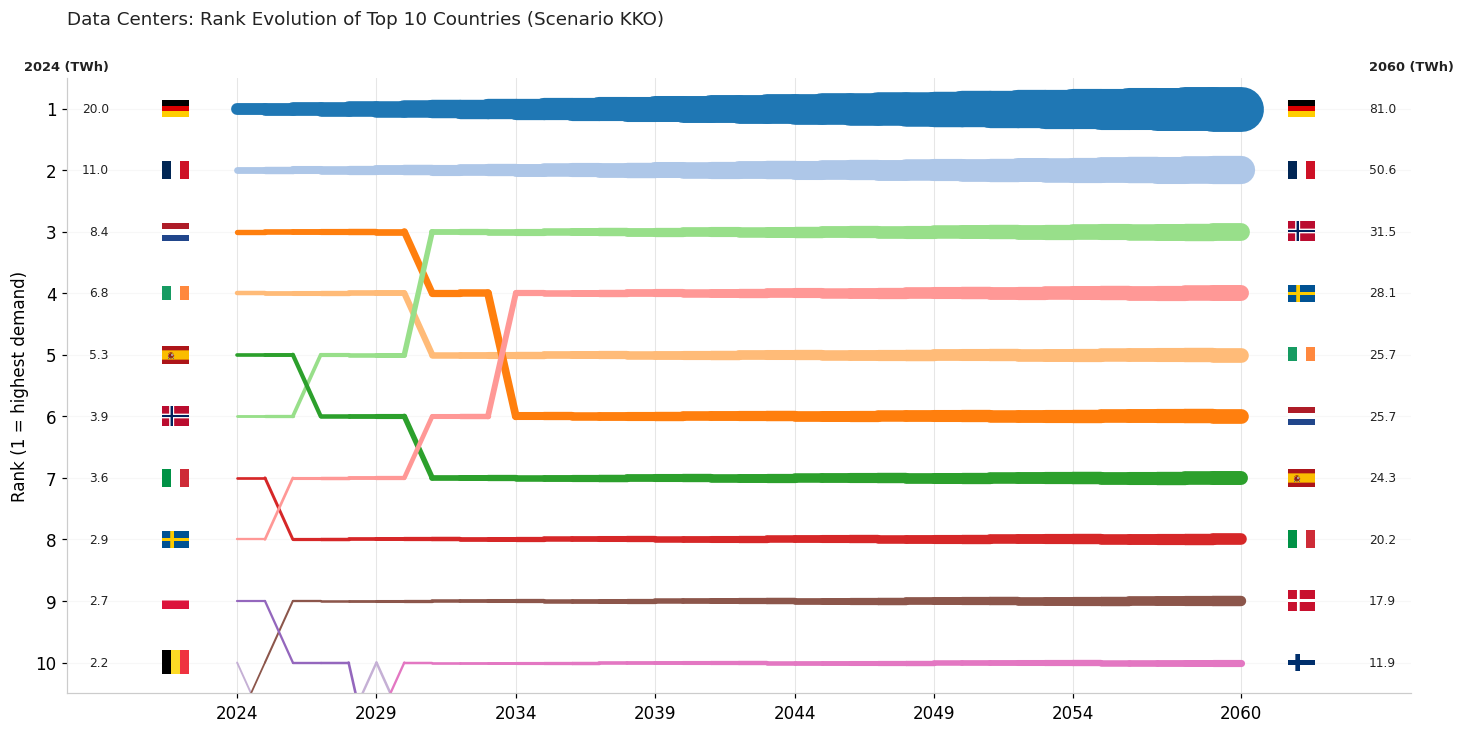

In [6]:
import urllib.request
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.collections import LineCollection

COUNTRY_ISO2 = {
    "Austria": "at", "Belgium": "be", "Bulgaria": "bg", "Croatia": "hr", "Czechia": "cz",
    "Denmark": "dk", "Estonia": "ee", "Finland": "fi", "France": "fr", "Germany": "de",
    "Greece": "gr", "Hungary": "hu", "Ireland": "ie", "Italy": "it", "Latvia": "lv",
    "Lithuania": "lt", "Luxembourg": "lu", "Netherlands": "nl", "Norway": "no", "Poland": "pl",
    "Portugal": "pt", "Romania": "ro", "Slovakia": "sk", "Slovenia": "si", "Spain": "es",
    "Sweden": "se",
}
FLAGDIR = "flags"
os.makedirs(FLAGDIR, exist_ok=True)

def get_flag(country, width=80):
    """Small flag PNG for a country, downloaded once from flagcdn.com and cached locally."""
    code = COUNTRY_ISO2[country]
    path = os.path.join(FLAGDIR, f"{code}.png")
    if not os.path.exists(path):
        urllib.request.urlretrieve(f"https://flagcdn.com/w{width}/{code}.png", path)
    return plt.imread(path)

def dc_bump(scenario="KKO", top_n=10, flag_zoom=0.22, lw_range=(1.0, 30.00)):
    d = dc[dc.scenario == scenario]
    pivot = d.pivot(index="year", columns="country", values="Demand_DC_TWh").fillna(0)
    ranks = pivot.rank(axis=1, ascending=False, method="first")
    years = pivot.index.values
    y0, y1 = years[0], years[-1]

    top_countries = ranks.columns[(ranks <= top_n).any()]
    country_colors = dc_country_colors(scenario)   # same colours as fig_dc_stacked

    # linewidth encodes demand: scaled from the min/max 2024-and-2060 demand across
    # the displayed countries, then interpolated linearly year-by-year (not the
    # actual, non-linear demand path) between the value at 2024 and at 2060
    lw_min, lw_max = lw_range
    v0_all = pivot.loc[y0, top_countries]; v1_all = pivot.loc[y1, top_countries]
    vmin, vmax = min(v0_all.min(), v1_all.min()), max(v0_all.max(), v1_all.max())

    def to_lw(v):
        return lw_min + (v - vmin) / (vmax - vmin) * (lw_max - lw_min)

    x_flag_left, x_flag_right = years.min() - 2.2, years.max() + 2.2
    x_val_left, x_val_right = years.min() - 4.6, years.max() + 4.6

    fig, ax = plt.subplots(figsize=(13.5, 6.8))
    for c in top_countries:
        r = ranks[c].values
        v0, v1 = pivot.loc[y0, c], pivot.loc[y1, c]
        lw0, lw1 = to_lw(v0), to_lw(v1)

        points = np.array([years, r]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        frac = (years[:-1] - y0) / (y1 - y0)
        seg_lw = lw0 + (lw1 - lw0) * frac
        lc = LineCollection(segments, linewidths=seg_lw, colors=[country_colors[c]] * len(segments),
                             capstyle="round", joinstyle="round", zorder=2)
        ax.add_collection(lc)

        flag = get_flag(c)
        r0, r1 = ranks.loc[y0, c], ranks.loc[y1, c]
        # only show a flag/value at an end where the country is actually in the top_n
        if r0 <= top_n:
            im = OffsetImage(flag, zoom=flag_zoom)
            ab = AnnotationBbox(im, (x_flag_left, r0), frameon=False, box_alignment=(0.5, 0.5), zorder=3)
            ab.set_clip_on(False); ax.add_artist(ab)
            ax.text(x_val_left, r0, f"{v0:.1f}", ha="right", va="center", fontsize=8, color=INK)
        if r1 <= top_n:
            im = OffsetImage(flag, zoom=flag_zoom)
            ab = AnnotationBbox(im, (x_flag_right, r1), frameon=False, box_alignment=(0.5, 0.5), zorder=3)
            ab.set_clip_on(False); ax.add_artist(ab)
            ax.text(x_val_right, r1, f"{v1:.1f}", ha="left", va="center", fontsize=8, color=INK)

    ax.text(x_val_left, 0.42, f"{y0} (TWh)", ha="right", va="bottom", fontsize=8.5, color=INK, fontweight="bold")
    ax.text(x_val_right, 0.42, f"{y1} (TWh)", ha="left", va="bottom", fontsize=8.5, color=INK, fontweight="bold")

    ax.set_xlim(x_val_left - 1.5, x_val_right + 1.5)
    ax.set_ylim(top_n + 0.5, 0.5)
    ax.set_yticks(range(1, top_n + 1))
    xticks = sorted(set([yr for yr in years[::5] if yr <= y1 - 3] + [y0, y1]))
    ax.set_xticks(xticks)
    ax.set_ylabel("Rank (1 = highest demand)")
    ax.set_title(f"Data Centers: Rank Evolution of Top {top_n} Countries (Scenario {scenario})",
                 loc="left", fontsize=12, color=INK, pad=35)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    save(fig, "fig_dc_bump")
    plt.show()

dc_bump("KKO", top_n=10)

## 4. Gebäudebestand

### 4.1 Beobachtete vs. konstante Bauaktivität

Historischer Neubau rekonstruiert aus dem Zuwachs der Kohorte 2011-2020 (Jahresdifferenz der
Kohortenfläche). Gestrichelt: alte Annahme einer konstanten Rate (BSO-Kohorte geteilt durch
zehn Jahre).

Sechs Länder, deren Bauaktivität sich nach der Finanzkrise 2008 sehr unterschiedlich entwickelt
hat.

saved figures/fig_newbuild.png


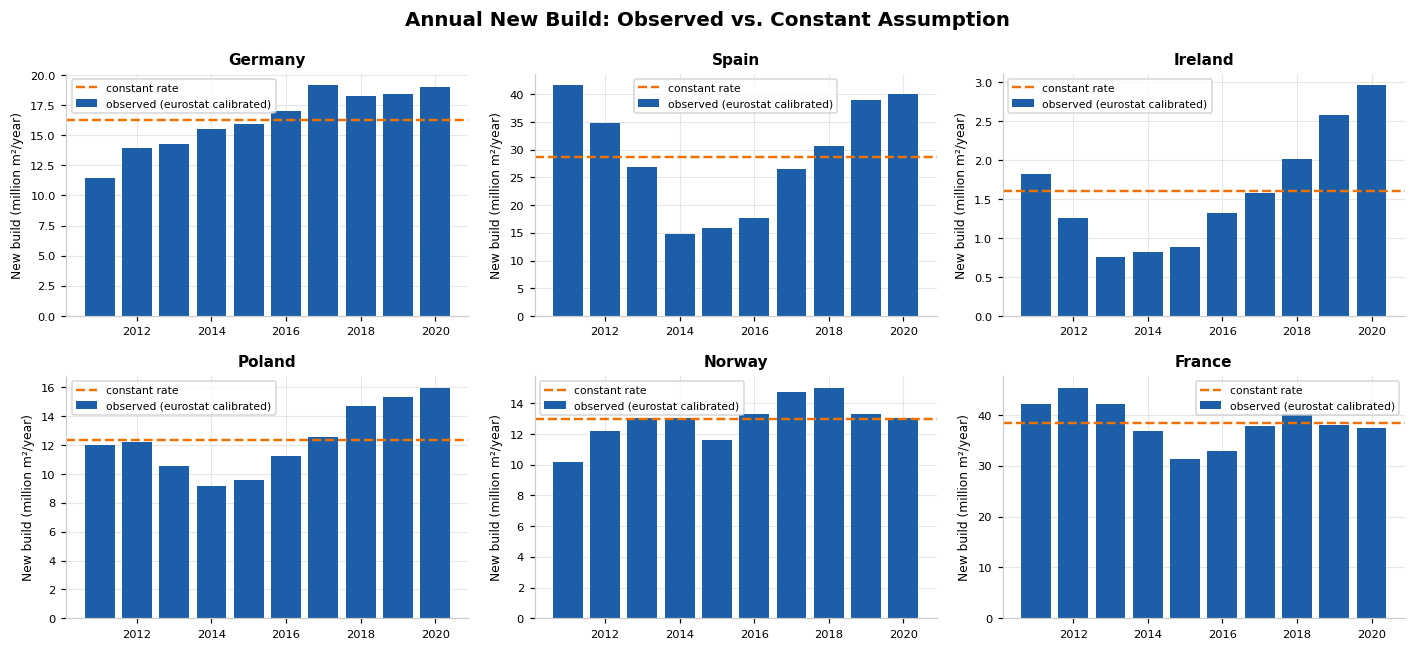

In [7]:
def reconstructed_newbuild(country):
    """Annual new build (mio m2) 2011-2024 from the growth of the 2011-2020 cohort."""
    h = floor[(floor.country == country) & (floor.scenario == "HIST")].sort_values("year")
    area_2011 = h["share_2011-2020"].values * h["total_floor_m2"].values
    nb = np.diff(area_2011)                      # yearly increment
    years = h["year"].values[1:]
    mask = years <= 2020                          # cohort only grows through 2020
    return years[mask], nb[mask] / 1e6

def flat_rate(country):
    """Old constant-rate assumption: BSO 2011-2020 cohort / 10 years, in mio m2."""
    row = floor[(floor.country == country) & (floor.scenario == "HIST") &
                (floor.year == 2020)].iloc[0]
    return row["share_2011-2020"] * row["total_floor_m2"] / 10 / 1e6

PANEL = ["Germany", "Spain", "Ireland", "Poland", "Norway", "France"]
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, c in zip(axes.flatten(), PANEL):
    yrs, nb = reconstructed_newbuild(c)
    ax.bar(yrs, nb, color=BLUE, label="observed (eurostat calibrated)")
    ax.axhline(flat_rate(c), color=ORANGE, lw=1.6, ls="--", label="constant rate")
    ax.set_title(c, fontweight="bold", fontsize=10)
    ax.set_ylabel("New build (million m²/year)", fontsize=8)
    ax.tick_params(labelsize=7.5)
    ax.legend(fontsize=7)
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Annual New Build: Observed vs. Constant Assumption",
             fontweight="bold", fontsize=13)
plt.tight_layout()
save(fig, "fig_newbuild")
plt.show()

### 4.2 Berechnung des thermal_index (Deutschland 2020)

Balkenhöhe = Heizintensität der Kohorte, Balkenbreite = ihr Flächenanteil (auch als Zahl im
Balken). Gestrichelte Linie = flächengewichteter Mittelwert = thermal_index.

saved figures/fig_thermal_calc.png


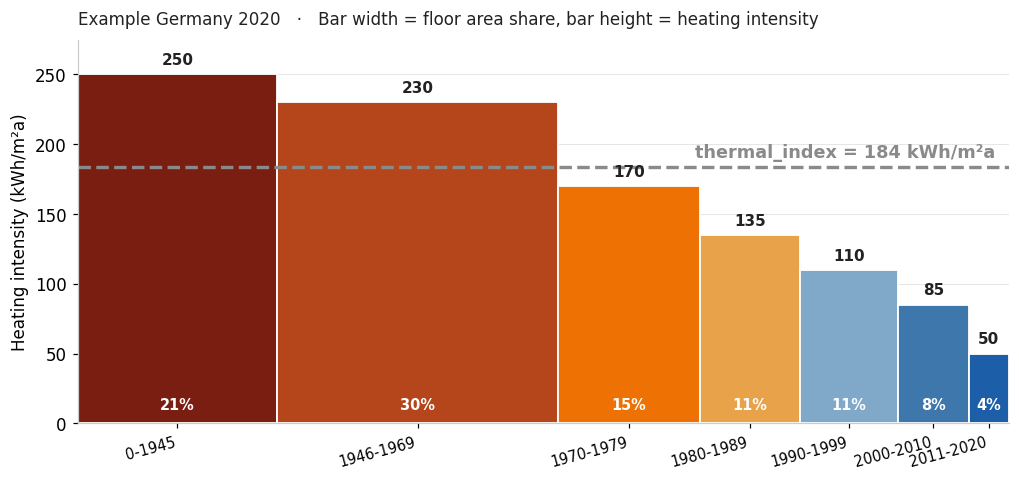

In [8]:
COHORTS = ["0-1945", "1946-1969", "1970-1979", "1980-1989",
           "1990-1999", "2000-2010", "2011-2020"]
row = floor[(floor.country == COUNTRY) & (floor.scenario == "HIST") &
            (floor.year == 2020)].iloc[0]
shares = {c: row[f"share_{c}"] for c in COHORTS}
ti = row["thermal_index"]

# bar width = cohort's share of total floor area, normalised so the widths still sum to
# len(COHORTS) (i.e. the chart spans the same total width as the equal-width version)
n = len(COHORTS)
shares_arr = np.array([shares[c] for c in COHORTS])
widths = shares_arr / shares_arr.sum() * n
lefts = np.concatenate(([0], np.cumsum(widths)[:-1]))
centers = lefts + widths / 2

fig, ax = plt.subplots(figsize=(9.4, 4.5))
ax.bar(lefts, [INTENSITY[c] for c in COHORTS], width=widths, align="edge",
       color=[COH_COL[c] for c in COHORTS], edgecolor="white", linewidth=1.2)
for x, c in zip(centers, COHORTS):
    ax.text(x, INTENSITY[c] + 5, f"{INTENSITY[c]}", ha="center", va="bottom",
            fontsize=10, color=INK, fontweight="bold")
    ax.text(x, 8, f"{shares[c]*100:.0f}%", ha="center", va="bottom",
            fontsize=9.5, color="white", fontweight="bold")
ax.axhline(ti, color=GRAY, lw=2.2, ls="--")
ax.text(n - 0.1, ti + 4, f"thermal_index = {ti:.0f} kWh/m²a",
        ha="right", va="bottom", fontsize=11.5, color=GRAY, fontweight="bold")
ax.set_xticks(centers); ax.set_xticklabels(COHORTS, fontsize=9.5, rotation=15, ha="right")
ax.set_xlim(0, n)
ax.set_ylabel("Heating intensity (kWh/m²a)"); ax.set_ylim(0, 275)
ax.set_title(f"Example {COUNTRY} 2020   ·   Bar width = floor area share, bar height = heating intensity",
             fontsize=11, color=INK, loc="left", pad=10)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", visible=False)
plt.tight_layout()
save(fig, "fig_thermal_calc")
plt.show()

### 4.3 Flächenentwicklung nach Baualtersklasse

Gestapelte Fläche für ein Land/Szenario, Historie + Projektion. Renovierte Kohorten
(`share_ren_*`) zusammengefasst zu einem Band *renovated*. Legende außerhalb der Zeichenfläche,
sonst verdeckt sie den Stapel.

saved figures/fig_stock_evolution.png


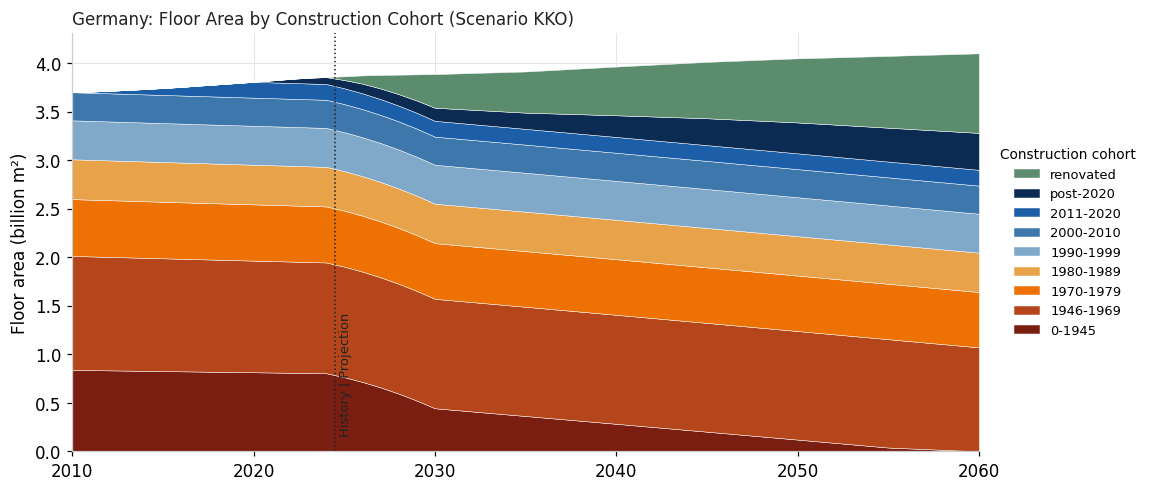

In [9]:
STOCK_SCENARIO = "KKO"
DISP = ["0-1945", "1946-1969", "1970-1979", "1980-1989", "1990-1999",
        "2000-2010", "2011-2020", "post-2020", "renovated"]
REN_COLS = [f"share_ren_{c}" for c in
            ["0-1945", "1946-1969", "1970-1979", "1980-1989", "1990-1999", "2000-2010"]]

def stock_frame(country, scenario):
    h = floor[(floor.country == country) & (floor.scenario == "HIST")]
    p = floor[(floor.country == country) & (floor.scenario == scenario)]
    return pd.concat([h, p]).sort_values("year")

def disp_areas(row):
    tot = row["total_floor_m2"]
    out = {c: row[f"share_{c}"] * tot for c in
           ["0-1945", "1946-1969", "1970-1979", "1980-1989",
            "1990-1999", "2000-2010", "2011-2020", "post-2020"]}
    out["renovated"] = sum(row[rc] for rc in REN_COLS) * tot
    return out

g = stock_frame(COUNTRY, STOCK_SCENARIO)
years = g["year"].values
M = np.array([[disp_areas(r)[c] / 1e9 for _, r in g.iterrows()] for c in DISP])

fig, ax = plt.subplots(figsize=(10.6, 4.6))
ax.stackplot(years, M, labels=DISP, colors=[COH_COL[c] for c in DISP],
             edgecolor="white", linewidth=0.3)
ax.axvline(2024.5, color=INK, lw=1, ls=":")
ax.text(2024.7, 0.15, "History | Projection", fontsize=8.5, color=INK, rotation=90, va="bottom")
ax.set_xlim(2010, 2060); ax.set_ylim(0, None)
ax.set_ylabel("Floor area (billion m²)")
ax.set_title(f"{COUNTRY}: Floor Area by Construction Cohort (Scenario {STOCK_SCENARIO})",
             fontsize=11, color=INK, loc="left")
h_, l_ = ax.get_legend_handles_labels()
ax.legend(h_[::-1], l_[::-1], loc="center left", bbox_to_anchor=(1.01, 0.5),
          fontsize=8.5, frameon=False, title="Construction cohort", title_fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
save(fig, "fig_stock_evolution")
plt.show()

### 4.4 thermal_index nach Szenario

Historie (schwarz) + vier Szenario-Pfade. Der Knick um 2030 kommt von der
Sanierungsraten-Rampe (steigt 2025-2030 linear auf ihren Zielwert, danach konstant).

saved figures/fig_ti_scenarios.png


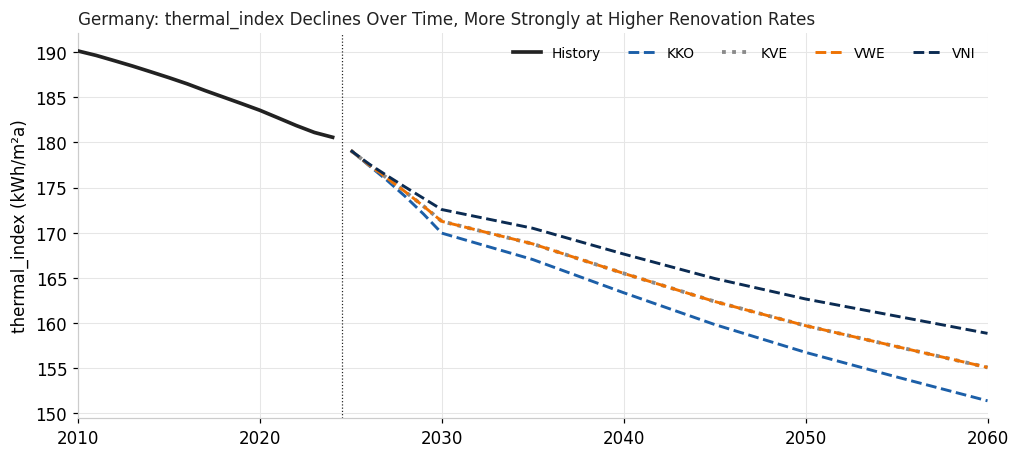

In [10]:
hist = floor[(floor.country == COUNTRY) & (floor.scenario == "HIST")].sort_values("year")

fig, ax = plt.subplots(figsize=(9.4, 4.3))
ax.plot(hist.year, hist.thermal_index, color=INK, lw=2.4, label="History", zorder=5)
for sc in ["KKO", "KVE", "VWE", "VNI"]:
    s = floor[(floor.country == COUNTRY) & (floor.scenario == sc)].sort_values("year")
    if sc != "KVE":
        ax.plot(s.year, s.thermal_index, color=SC_COL[sc], lw=1.9, ls="--", label=sc)
    if sc == "KVE":
        ax.plot(s.year, s.thermal_index, color=SC_COL[sc], lw=2.5, ls=":", label=sc)
ax.axvline(2024.5, color=INK, lw=0.8, ls=":")
ax.set_xlim(2010, 2060); ax.set_ylabel("thermal_index (kWh/m²a)")
ax.set_title(f"{COUNTRY}: thermal_index Declines Over Time, More Strongly at Higher Renovation Rates",
             fontsize=11, color=INK, loc="left")
ax.legend(ncol=5, fontsize=9, frameon=False, loc="upper right")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
save(fig, "fig_ti_scenarios")
plt.show()

## 5. Heat Pumps und Buildings: Ergebnisgitter

Ein Panel pro Modell, alle 26 Länder, vier Szenario-Linien je Land. `country_grid` baut beide
Gitter mit demselben Layout.

In [11]:
def country_grid(df, valcol, title, fname, n_cols=5, ymax=None):
    countries = sorted(df.country.unique())
    n_rows = int(np.ceil(len(countries) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.5, n_rows * 2.5))
    axes = axes.flatten()
    for ax, c in zip(axes, countries):
        sub = df[df.country == c]
        for sc in ["KKO", "KVE", "VWE", "VNI"]:
            d = sub[sub.scenario == sc].sort_values("year")
            if len(d):
                ax.plot(d.year, d[valcol], color=SC_COL[sc], lw=1.5, label=sc)
        ax.set_title(c, fontsize=9.5, fontweight="bold")
        ax.tick_params(labelsize=6.5)
        ax.set_ylim(bottom=0, top=ymax)
        ax.grid(alpha=0.25)
        ax.spines[["top", "right"]].set_visible(False)
    for ax in axes[len(countries):]:
        ax.set_visible(False)
    h_, l_ = axes[0].get_legend_handles_labels()
    fig.legend(h_, l_, loc="upper center", ncol=4, fontsize=11, bbox_to_anchor=(0.5, 1.03))
    fig.suptitle(title, fontsize=14, fontweight="bold", y=1.06)
    plt.tight_layout()
    save(fig, fname)
    plt.show()

### 5.1 Heat Pumps: Strombedarf je Land und Szenario

saved figures/fig_hp_grid.png


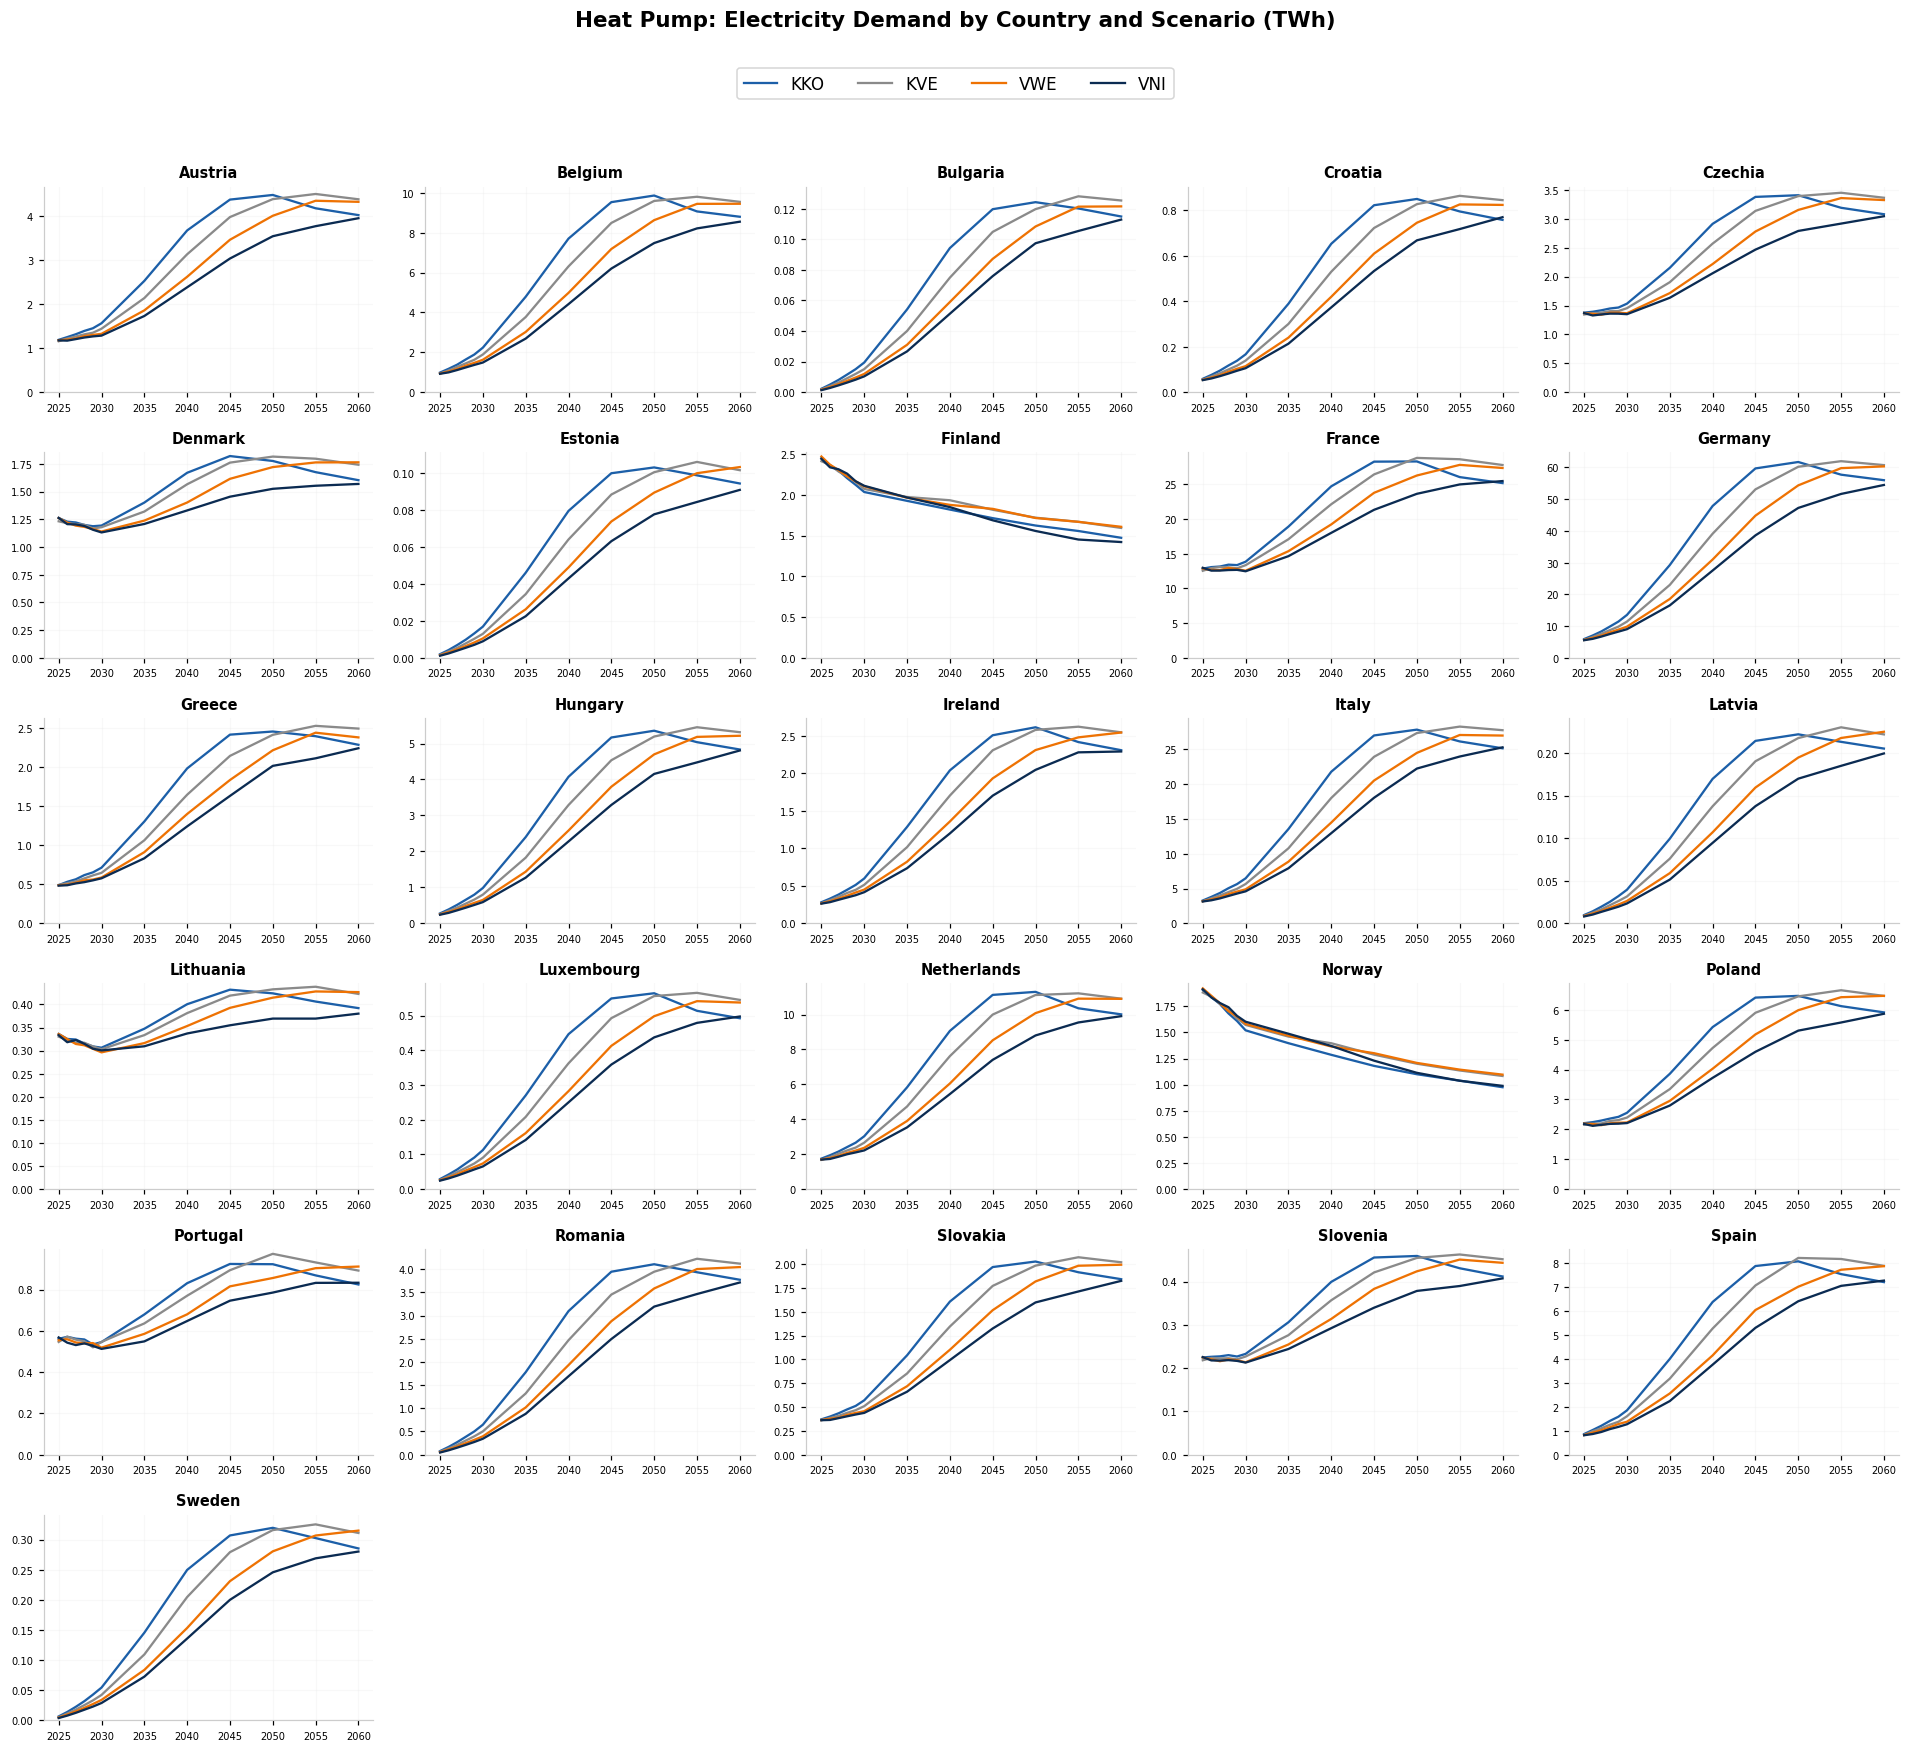

In [12]:
country_grid(hp, "Demand_HP_TWh",
             "Heat Pump: Electricity Demand by Country and Scenario (TWh)", "fig_hp_grid")

### 5.2 Buildings (Rest): Strombedarf je Land und Szenario

saved figures/fig_br_grid.png


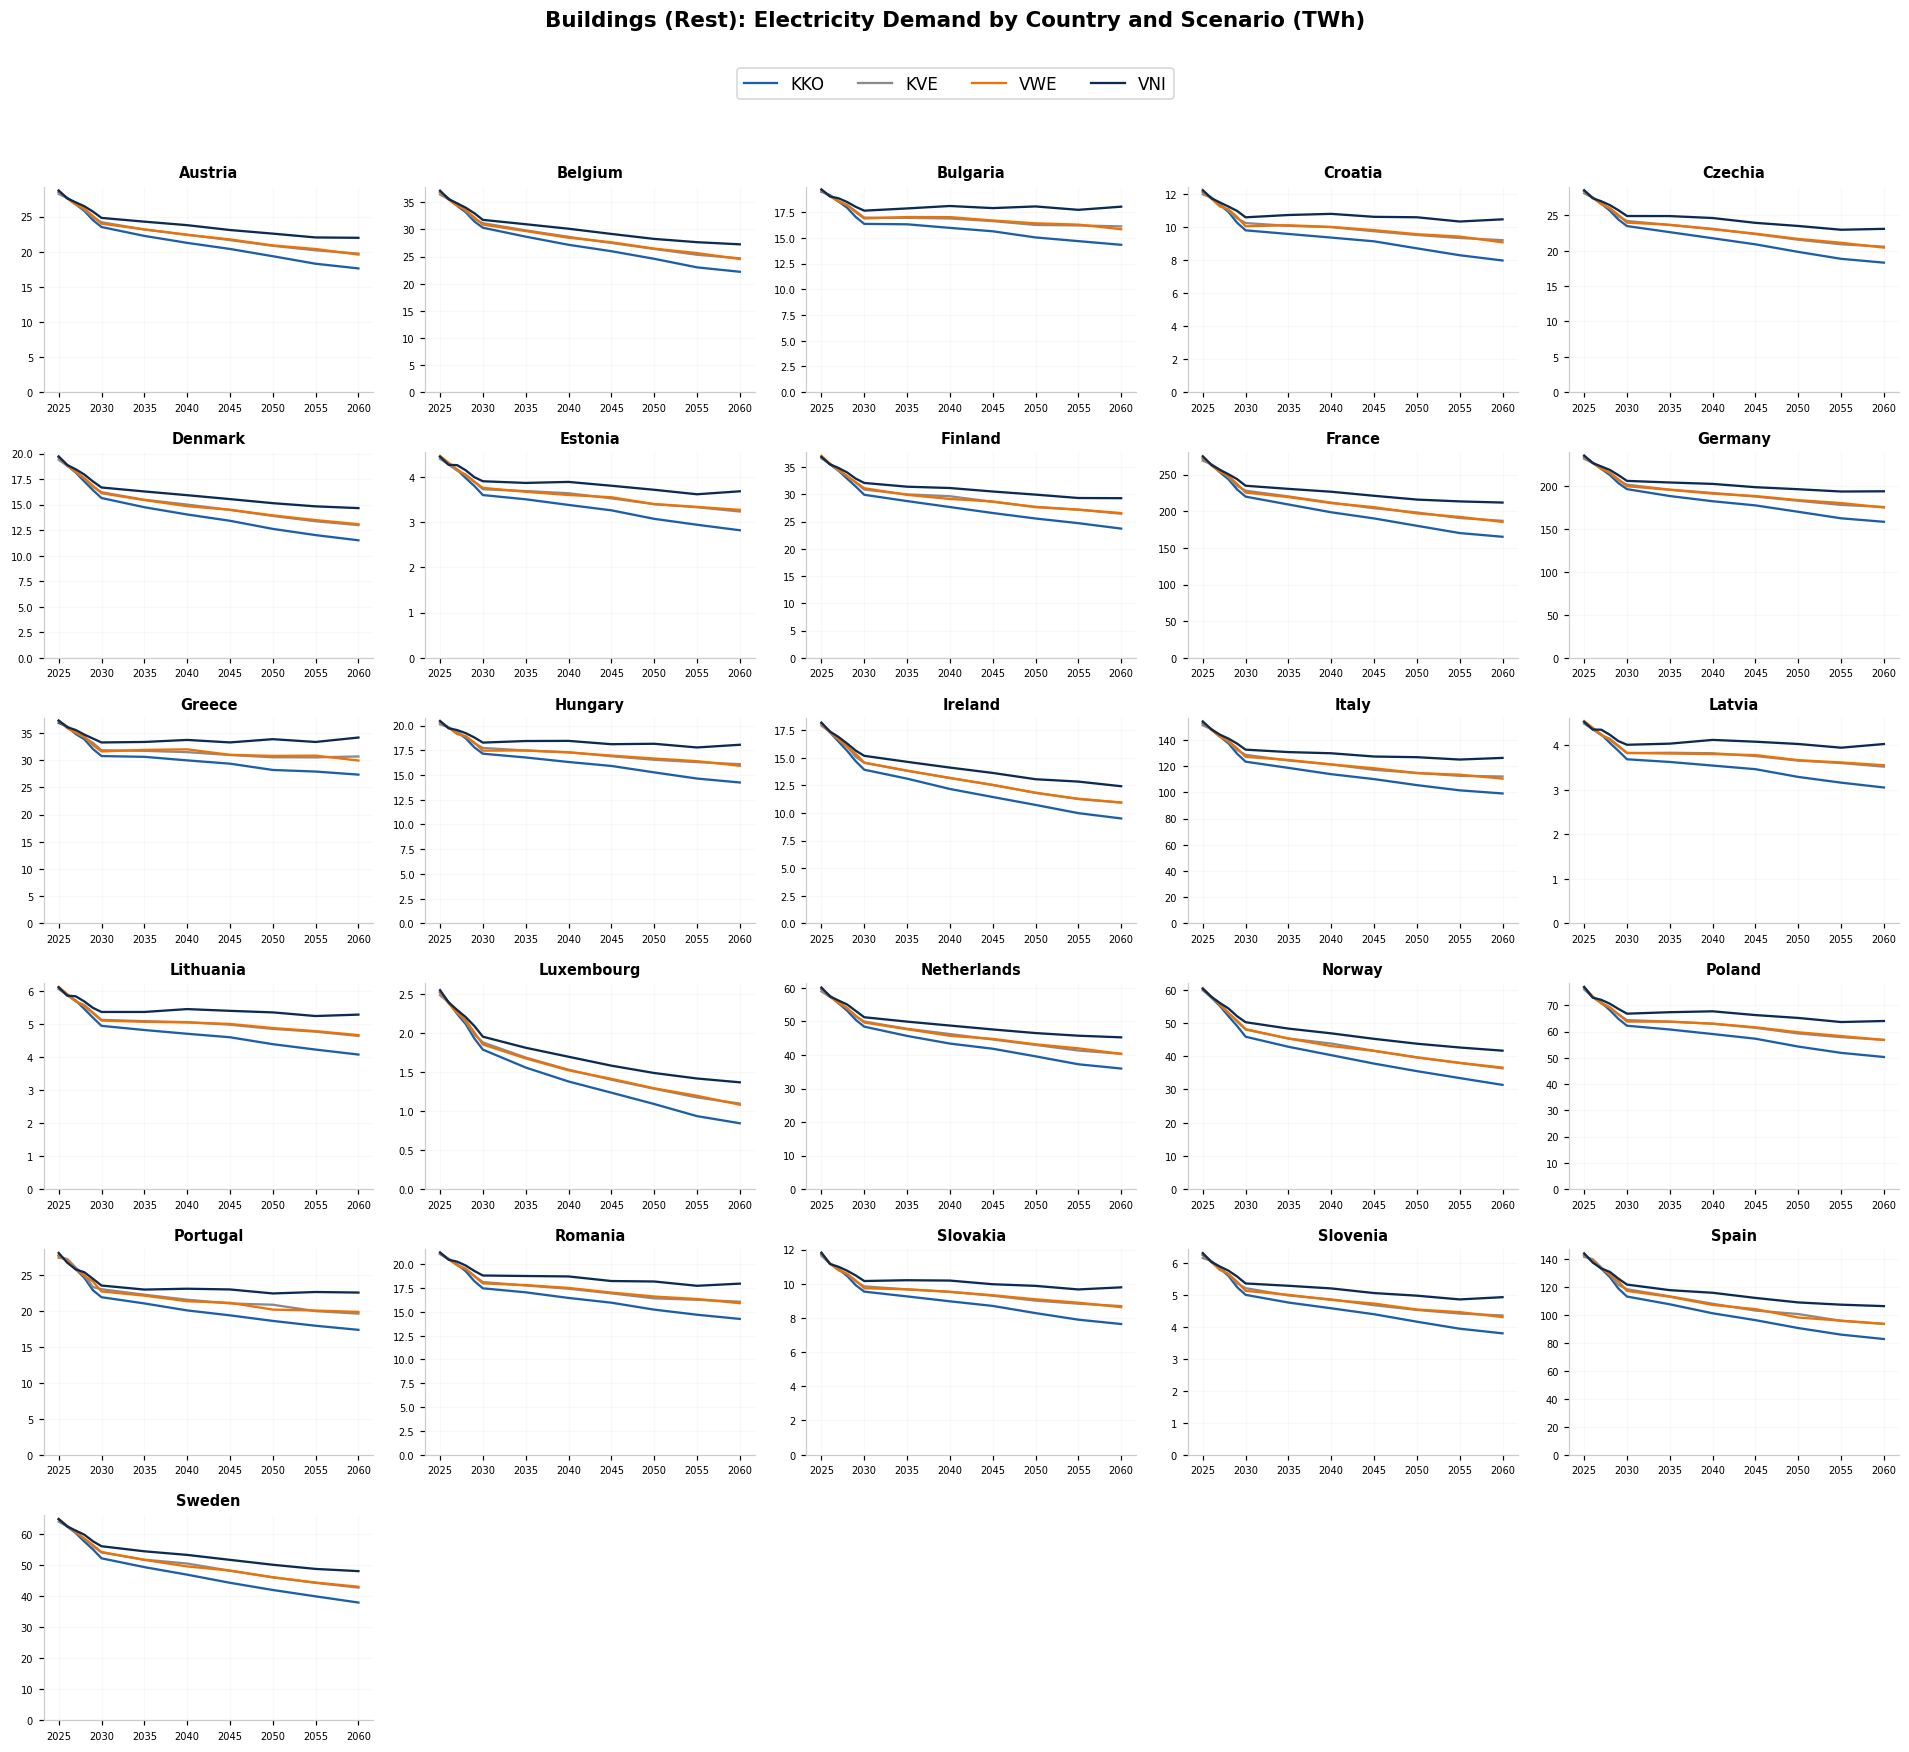

In [13]:
country_grid(build, "panel_predictions",
             "Buildings (Rest): Electricity Demand by Country and Scenario (TWh)", "fig_br_grid")

### 5.3 Heat Pumps: Anteil Wärmepumpen je Land und Szenario

saved figures/fig_hp_share.png


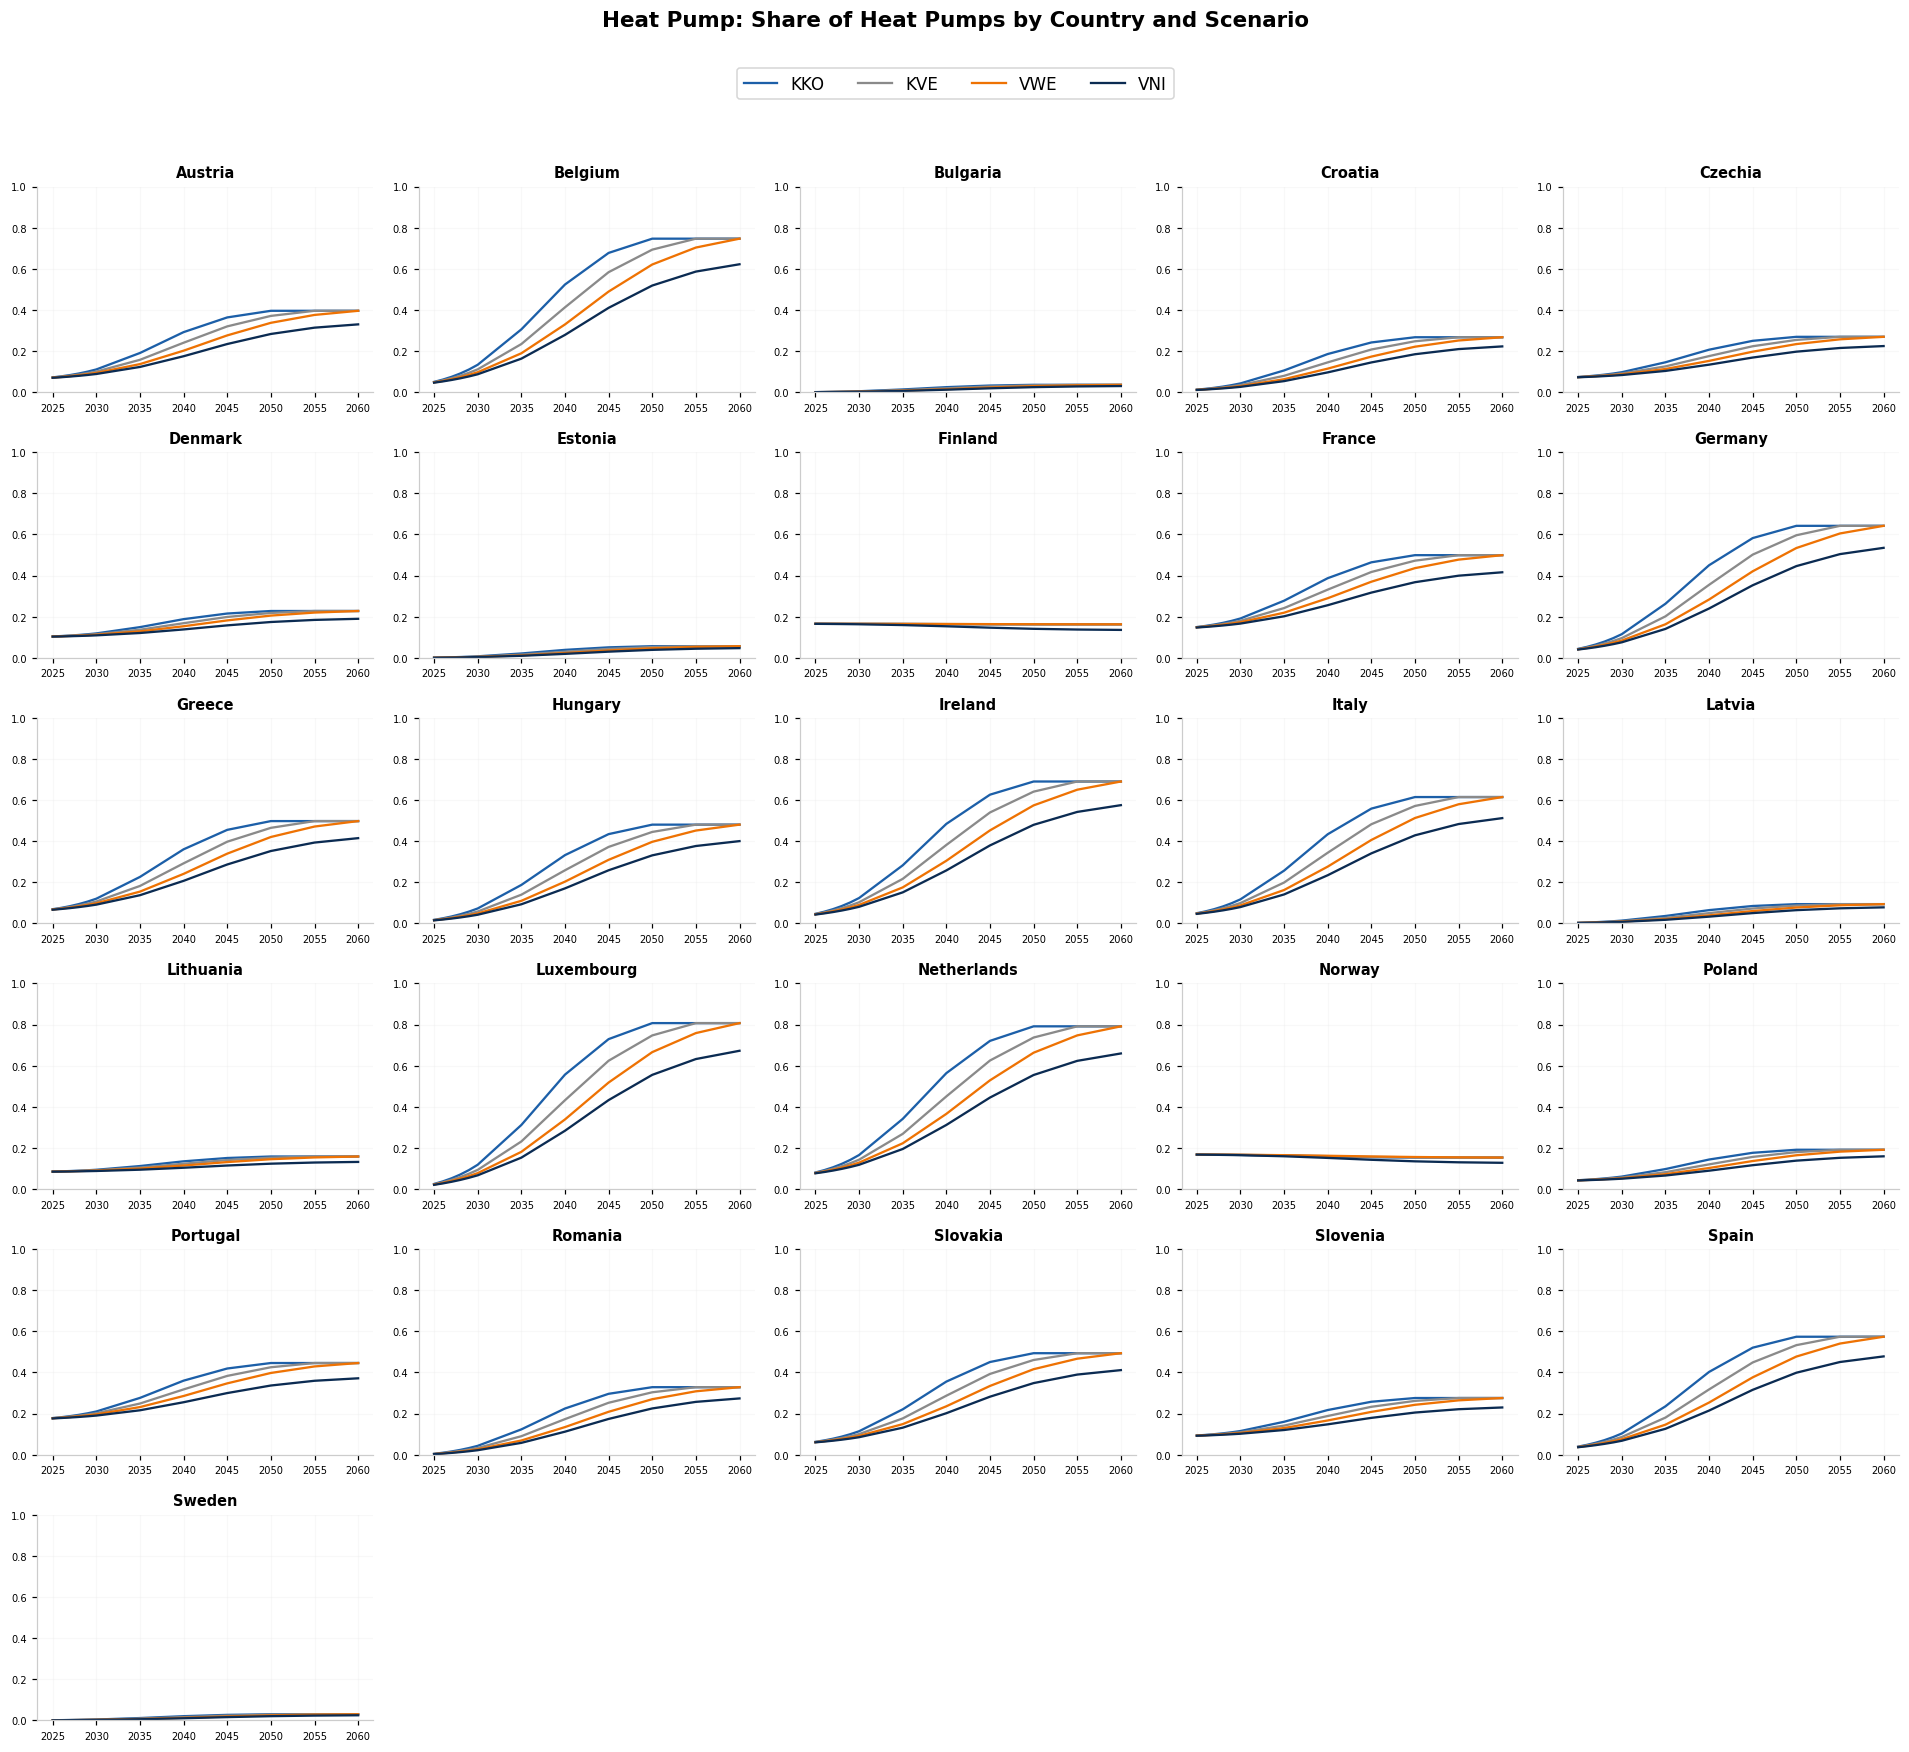

In [14]:
country_grid(hp, "share_pu",
             "Heat Pump: Share of Heat Pumps by Country and Scenario", "fig_hp_share", ymax=1)

## 6. Gesamt: Summe aus Heat Pumps, Buildings (Rest) und Data Centers

Summe des Strombedarfs aller drei Modelle je Land, Jahr, Szenario. `hp`/`build` starten erst
2025, `dc` schon 2024 – daher Inner-Join, nur gemeinsame Jahre 2025–2060.

In [15]:
total = (
    hp[["country", "year", "scenario", "Demand_HP_TWh"]]
    .merge(build[["country", "year", "scenario", "panel_predictions"]],
           on=["country", "year", "scenario"])
    .merge(dc[["country", "year", "scenario", "Demand_DC_TWh"]],
           on=["country", "year", "scenario"])
    .rename(columns={"panel_predictions": "Demand_Build_TWh"})
)
total["Demand_Total_TWh"] = (total["Demand_HP_TWh"] + total["Demand_Build_TWh"]
                              + total["Demand_DC_TWh"])

print(f"total : {total.shape[0]:5d} rows | {total.country.nunique()} countries | "
      f"years {total.year.min()}-{total.year.max()} | scenarios {sorted(total.scenario.unique())}")

total :  1248 rows | 26 countries | years 2025-2060 | scenarios ['KKO', 'KVE', 'VNI', 'VWE']


### 6.1 EU-26 Gesamtnachfrage gestapelt nach Sektor

Welcher Sektor treibt das Wachstum der Gesamtnachfrage (Standard: Szenario KKO).

saved figures/fig_total_stack_eu.png


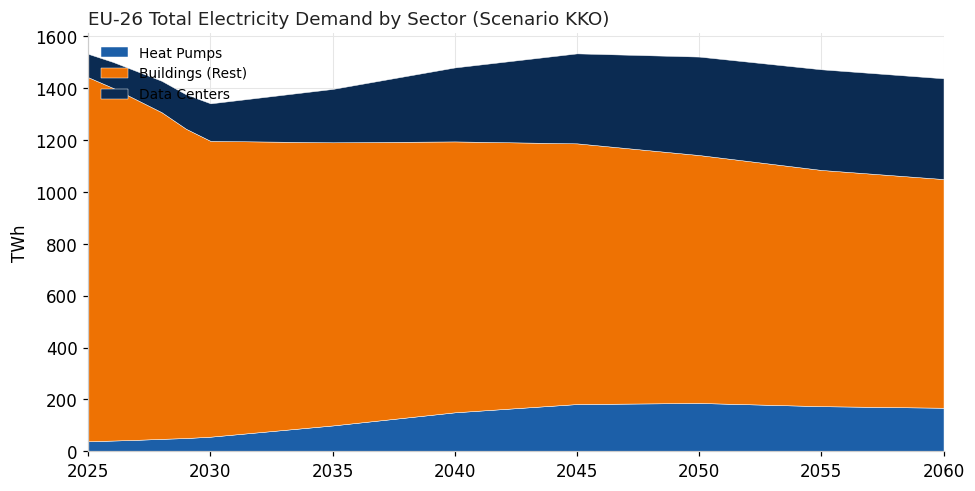

In [16]:
SECTOR_COL = {"Heat Pumps": BLUE, "Buildings (Rest)": ORANGE, "Data Centers": NAVY}
SECTOR_VALCOL = {"Heat Pumps": "Demand_HP_TWh", "Buildings (Rest)": "Demand_Build_TWh",
                 "Data Centers": "Demand_DC_TWh"}

def total_stack_eu(scenario="KKO"):
    d = total[total.scenario == scenario]
    g = d.groupby("year")[list(SECTOR_VALCOL.values())].sum()
    years = g.index.values

    fig, ax = plt.subplots(figsize=(9.0, 4.6))
    ax.stackplot(years, *[g[SECTOR_VALCOL[s]] for s in SECTOR_COL],
                 labels=list(SECTOR_COL.keys()), colors=list(SECTOR_COL.values()),
                 edgecolor="white", linewidth=0.3)
    ax.set_xlim(years.min(), years.max()); ax.set_ylim(0, None)
    ax.set_ylabel("TWh")
    ax.set_title(f"EU-26 Total Electricity Demand by Sector (Scenario {scenario})",
                 loc="left", fontsize=12, color=INK)
    ax.legend(loc="upper left", fontsize=9, frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    save(fig, "fig_total_stack_eu")
    plt.show()

total_stack_eu("KKO")

### 6.2 Gesamtnachfrage je Land und Szenario

`country_grid` (siehe Abschnitt 5), diesmal für die Summe aller drei Modelle.

saved figures/fig_total_grid.png


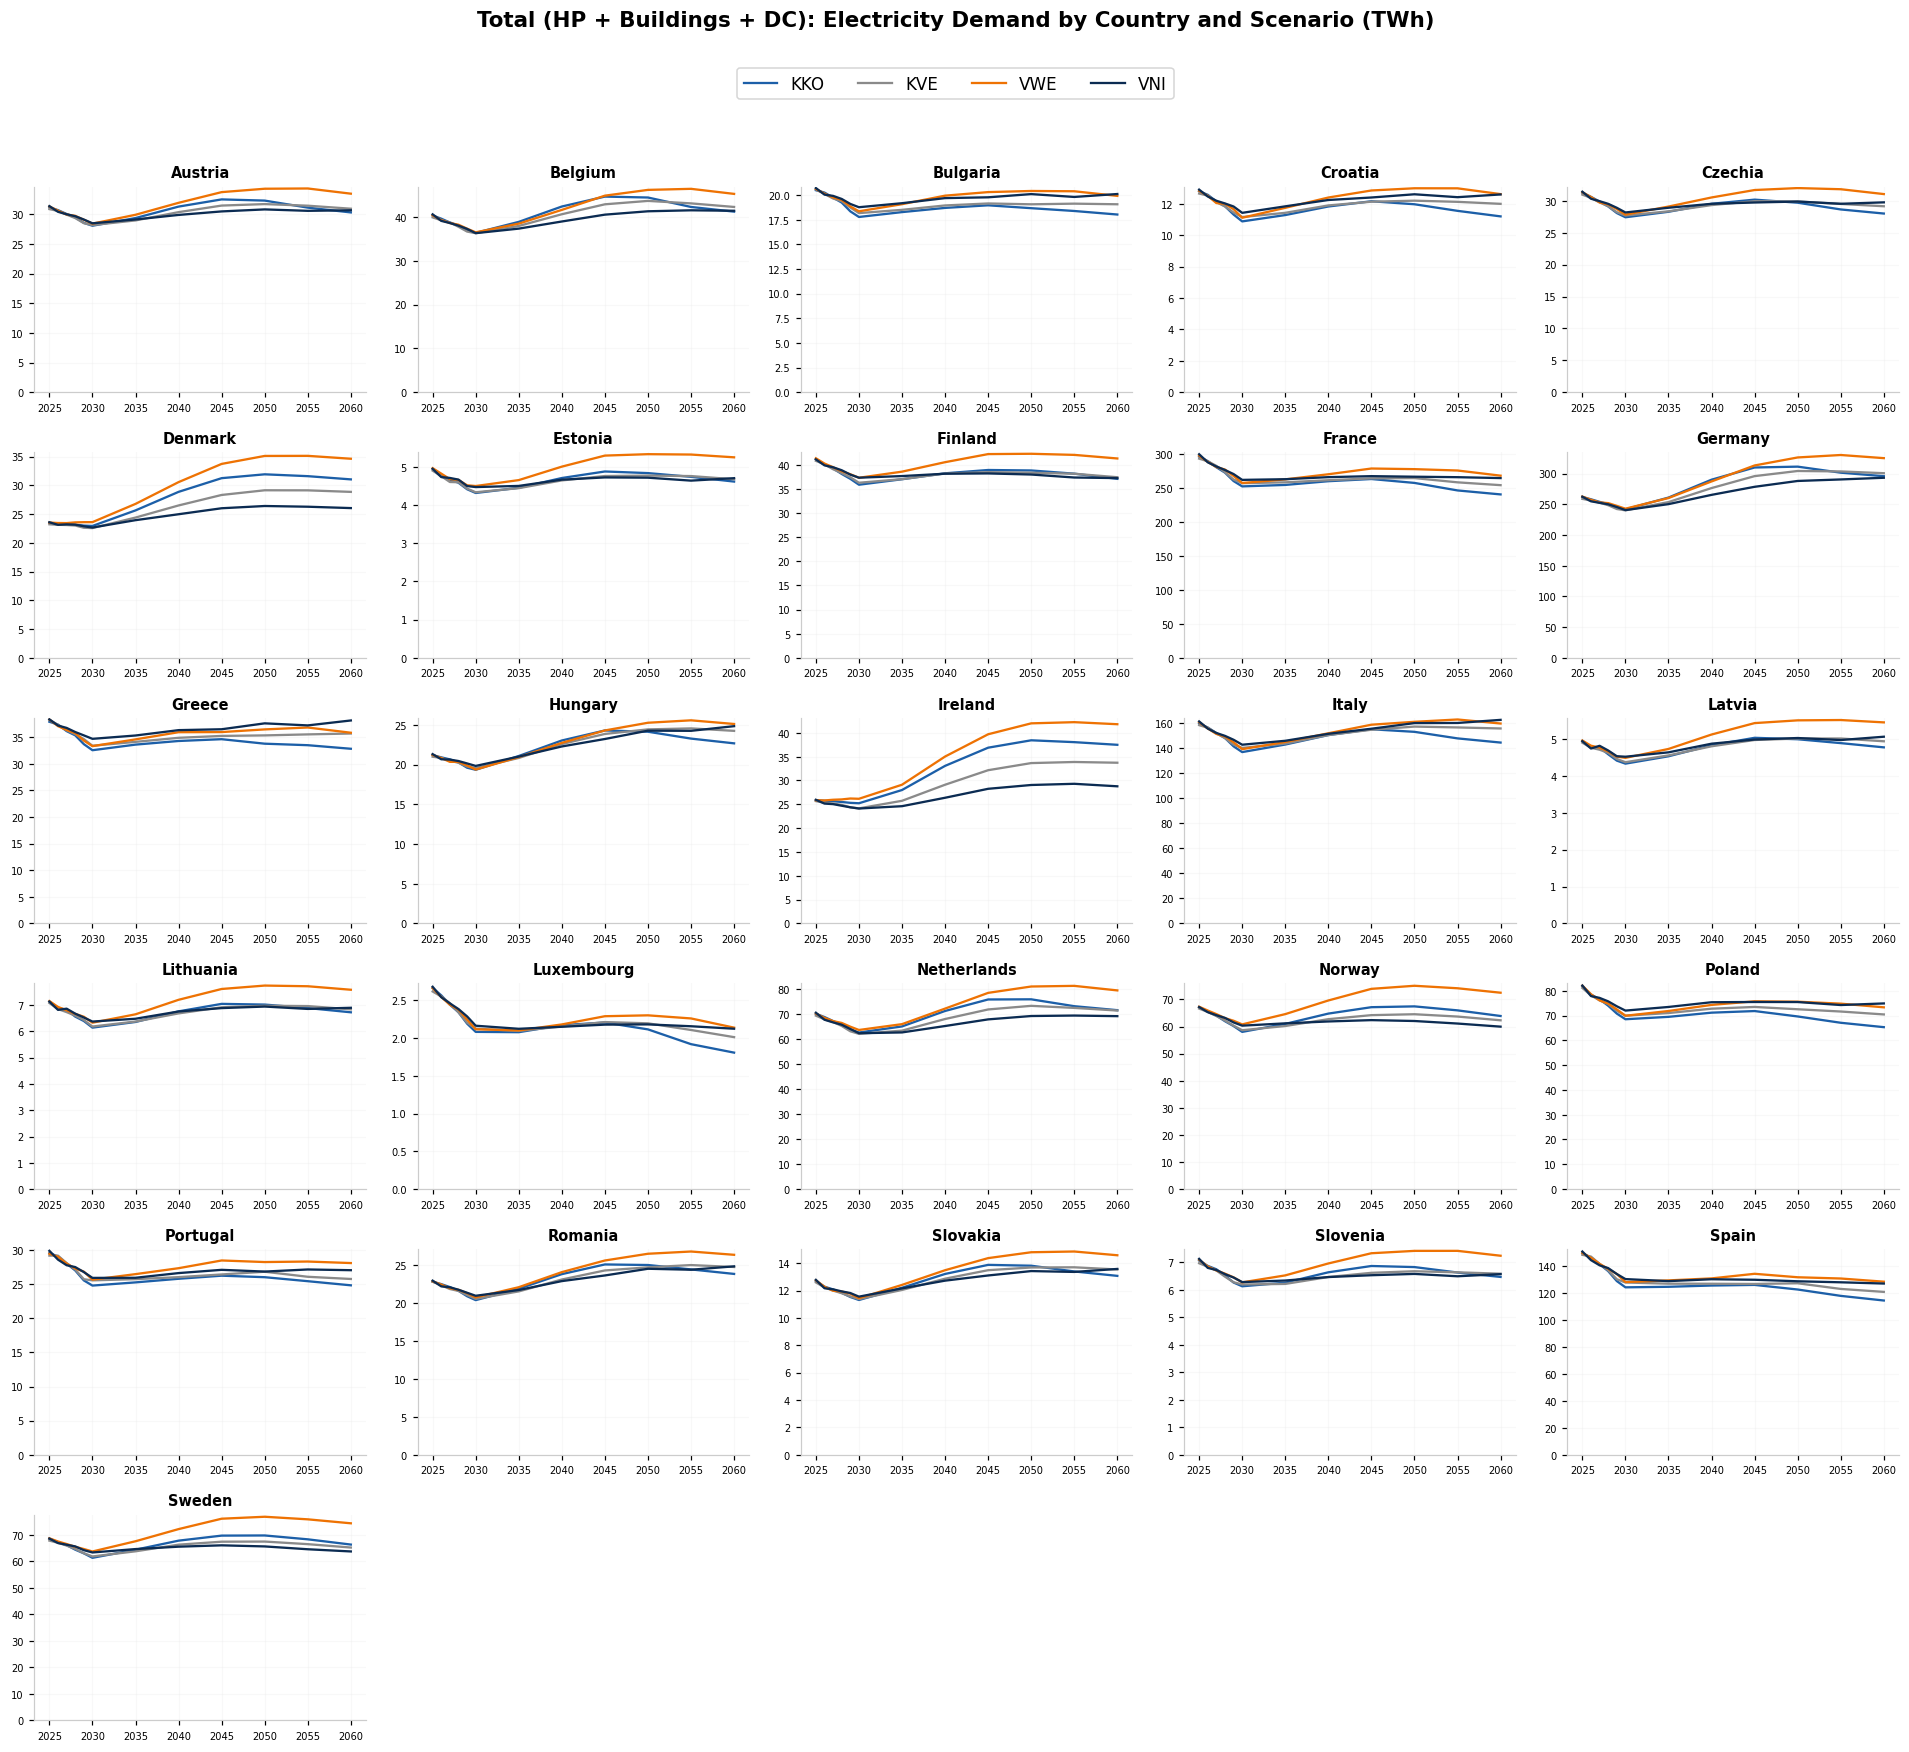

In [17]:
country_grid(total, "Demand_Total_TWh",
             "Total (HP + Buildings + DC): Electricity Demand by Country and Scenario (TWh)",
             "fig_total_grid")

### 6.3 Sektor-Mix der Gesamtnachfrage (Anteile)

Wie 6.1, aber als Anteile (100%-gestapelt) – zeigt die Verschiebung des Mixes direkter.

saved figures/fig_total_share_eu.png


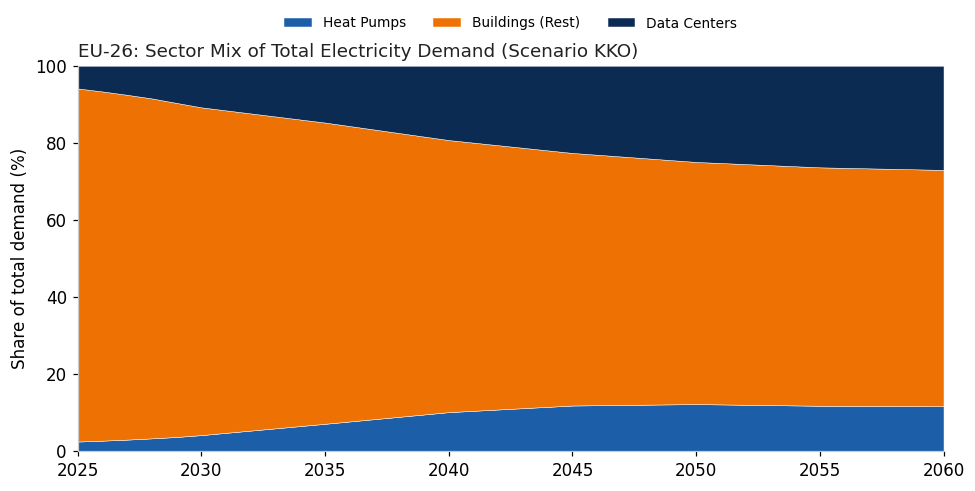

In [18]:
def total_share_eu(scenario="KKO"):
    d = total[total.scenario == scenario]
    g = d.groupby("year")[list(SECTOR_VALCOL.values())].sum()
    shares = g.div(g.sum(axis=1), axis=0) * 100
    years = g.index.values

    fig, ax = plt.subplots(figsize=(9.0, 4.6))
    ax.stackplot(years, *[shares[SECTOR_VALCOL[s]] for s in SECTOR_COL],
                 labels=list(SECTOR_COL.keys()), colors=list(SECTOR_COL.values()),
                 edgecolor="white", linewidth=0.3)
    ax.set_xlim(years.min(), years.max()); ax.set_ylim(0, 100)
    ax.set_ylabel("Share of total demand (%)")
    ax.set_title(f"EU-26: Sector Mix of Total Electricity Demand (Scenario {scenario})",
                 loc="left", fontsize=12, color=INK)
    ax.legend(loc="upper center", ncol=3, fontsize=9, frameon=False, bbox_to_anchor=(0.5, 1.16))
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    save(fig, "fig_total_share_eu")
    plt.show()

total_share_eu("KKO")

## 7. Fertig

Alle Grafiken liegen als PNG in `figures/`. Aussehen anpassen: Farben/Größen in Abschnitt 1
ändern; anderes Beispielland: `COUNTRY` (bzw. `STOCK_SCENARIO`) oben setzen und die
Bausteinzellen neu laufen lassen.

Nicht hier drin, weil direkt aus den Modell-Notebooks kommt:
- Heat-Pump-Backtesting-Bild
- Parameter-Tabellen (Regressionsausgaben)

In [19]:
print("Erzeugte Dateien:")
for f in sorted(os.listdir(OUTDIR)):
    print("  ", os.path.join(OUTDIR, f))

Erzeugte Dateien:
   figures/.DS_Store
   figures/1 percent historie
   figures/fig_br_grid.png
   figures/fig_dc_bump.png
   figures/fig_dc_countries.png
   figures/fig_dc_eu26.png
   figures/fig_dc_stacked.png
   figures/fig_hp_grid.png
   figures/fig_hp_share.png
   figures/fig_newbuild.png
   figures/fig_sensitivity.png
   figures/fig_stock_evolution.png
   figures/fig_thermal_calc.png
   figures/fig_ti_scenarios.png
   figures/fig_total_grid.png
   figures/fig_total_share_eu.png
   figures/fig_total_stack_eu.png
